In [ ]:
# Core libraries
import pandas as pd
import numpy as np
from pathlib import Path
import logging

# ML libraries
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Simple logging setup
logging.basicConfig(
    level=logging.INFO,
    format='%(levelname)s - %(message)s'
)
logger = logging.getLogger(__name__)

logger.info("Notebook initialized successfully")

---

## 0. Data Scraping

Scape the data from https://store.steampowered.com/appreviews/ and store them in a csv file.

In [88]:
import requests
import pandas as pd
import time
from pathlib import Path
from typing import List, Dict, Optional
import logging

In [ ]:
def scrape_steam_reviews(
    app_id: int,
    max_reviews: int = 50000,
    language: str = 'english',
    reviews_per_page: int = 100
) -> List[Dict]:
    """
    Scrape game reviews from Steam API.
    
    Parameters
    ----------
    app_id : int
        Steam application ID
    max_reviews : int
        Maximum number of reviews to collect
    language : str
        Review language filter
    reviews_per_page : int
        Number of reviews per API request (max 100)
        
    Returns
    -------
    List[Dict]
        List of review dictionaries
    """
    all_reviews = []
    cursor = '*'
    start_time = time.time()
    
    logging.info(f"Starting fetching reviews for app_id={app_id}...")
    
    while len(all_reviews) < max_reviews:
        url = f'https://store.steampowered.com/appreviews/{app_id}'
        params = {
            'json': 1,
            'language': language,
            'cursor': cursor,
            'num_per_page': reviews_per_page,
            'filter': 'recent'
        }
        
        try:
            response = requests.get(url, params=params, timeout=10)
            response.raise_for_status()
            data = response.json()
            
            if not data.get('reviews'):
                logging.warning("No more reviews available")
                break
            
            all_reviews.extend(data['reviews'])
            cursor = data.get('cursor')
            
            if not cursor:
                logging.warning("No cursor returned, ending pagination")
                break
            
            # Rate limiting: 0.3s between requests
            time.sleep(0.3)
            
        except requests.exceptions.RequestException as e:
            logging.error(f"Request failed: {e}")
            time.sleep(5)
    
    final_reviews = all_reviews[:max_reviews]
    elapsed_time = time.time() - start_time
    
    logging.info(f"Fetched {len(final_reviews)} reviews in {elapsed_time:.2f} seconds")
    
    return final_reviews

In [90]:
def fetch_game_details(app_id: int) -> Dict:
    """
    Fetch game metadata from Steam Store API.
    
    Parameters
    ----------
    app_id : int
        Steam application ID
        
    Returns
    -------
    Dict
        Game metadata including price, genres, description, etc.
    """
    url = f'https://store.steampowered.com/api/appdetails'
    params = {'appids': app_id}
    
    try:
        response = requests.get(url, params=params, timeout=10)
        response.raise_for_status()
        data = response.json()
        
        if str(app_id) in data and data[str(app_id)]['success']:
            game_data = data[str(app_id)]['data']
            logging.info(f"Fetched game details for '{game_data.get('name', 'Unknown')}'")
            return game_data
        else:
            logging.warning(f"Failed to fetch game details for app_id={app_id}")
            return {}
            
    except requests.exceptions.RequestException as e:
        logging.error(f"Request failed: {e}")
        return {}


def process_reviews(reviews: List[Dict], game_data: Dict = None) -> pd.DataFrame:
    """
    Convert raw review data to structured DataFrame.
    
    Parameters
    ----------
    reviews : List[Dict]
        Raw review data from Steam API
    game_data : Dict, optional
        Game metadata from appdetails API (price, genre, description, etc.)
        
    Returns
    -------
    pd.DataFrame
        Structured dataset with selected features for binary classification
    """
    data = []
    
    for review in reviews:
        author = review.get('author', {})
        
        record = {
            # Target variable
            'recommended': review.get('voted_up', False),
            
            # User attributes (descriptive features)
            'user_id': author.get('steamid', ''),
            'user_games_owned': author.get('num_games_owned', 0),
            'user_num_reviews': author.get('num_reviews', 0),
            
            # User-Game interaction (numeric features)
            'playtime_at_review_hours': author.get('playtime_at_review', 0) / 60,
            'playtime_total_hours': author.get('playtime_forever', 0) / 60,
            'playtime_recent_hours': author.get('playtime_last_two_weeks', 0) / 60,
            
            # Review metadata (categorical features)
            'received_free': review.get('received_for_free', False),
            'steam_purchase': review.get('steam_purchase', True),
            'written_early_access': review.get('written_during_early_access', False),
            
            # Review engagement (numeric features)
            'votes_helpful': review.get('votes_up', 0),
            'votes_funny': review.get('votes_funny', 0),
            'weighted_vote_score': review.get('weighted_vote_score', 0.0),
            'comment_count': review.get('comment_count', 0),
            
            # Temporal features
            'timestamp_created': review.get('timestamp_created', 0),
            'timestamp_updated': review.get('timestamp_updated', 0),
            
            # Text features (free text)
            'review_text': review.get('review', ''),
            'review_length': len(review.get('review', '')),
            
            # Unique identifiers
            'review_id': review.get('recommendationid', '')
        }
        
        # Add game features if game_data provided
        if game_data:
            record.update({
                'game_id': game_data.get('steam_appid', ''),
                'game_name': game_data.get('name', ''),
                'game_price': game_data.get('price_overview', {}).get('final', 0) / 100 if game_data.get('price_overview') else 0,
                'game_is_free': game_data.get('is_free', False),
                'game_genre': ','.join([g['description'] for g in game_data.get('genres', [])]),
                'game_categories': ','.join([c['description'] for c in game_data.get('categories', [])]),
                'game_developer': ','.join(game_data.get('developers', [])),
                'game_publisher': ','.join(game_data.get('publishers', [])),
                'game_description': game_data.get('short_description', ''),
                'game_required_age': game_data.get('required_age', 0),
            })
        
        data.append(record)
    
    df = pd.DataFrame(data)
    
    # Feature engineering
    df['playtime_ratio'] = df['playtime_at_review_hours'] / (df['playtime_total_hours'] + 1)
    df['review_engagement_score'] = df['votes_helpful'] + df['votes_funny'] * 0.5
    df['experienced_gamer'] = df['user_games_owned'] > 50
    df['active_reviewer'] = df['user_num_reviews'] > 5
    
    feature_count = len(df.columns)
    logging.info(f"Processed {len(df)} reviews into DataFrame with {feature_count} features")
    
    return df

In [91]:
# Configuration
APP_ID = 578080  # PUBG
MAX_REVIEWS = 50000
OUTPUT_FILE = 'steam_reviews.csv'

# Fetch game metadata first
logging.info(f"Fetching game metadata for app_id={APP_ID}...")
game_data = fetch_game_details(APP_ID)

# Collect reviews
logging.info(f"Starting to scrape reviews for app_id={APP_ID}...")
reviews = scrape_steam_reviews(app_id=APP_ID, max_reviews=MAX_REVIEWS)

INFO:root:Fetching game metadata for app_id=578080...
INFO:root:Fetched game details for 'PUBG: BATTLEGROUNDS'
INFO:root:Starting to scrape reviews for app_id=578080...
INFO:root:Starting fetching reviews for app_id=578080...
INFO:root:Fetched 22700 reviews in 180.59 seconds


In [92]:
# Process reviews with game data and save to CSV
df = process_reviews(reviews, game_data=game_data)
df.to_csv(OUTPUT_FILE, index=False)
logging.info(f"Dataset saved to {OUTPUT_FILE}")

INFO:root:Processed 22700 reviews into DataFrame with 33 features
INFO:root:Dataset saved to steam_reviews.csv


In [93]:
# Data summary
print(f"Dataset shape: {df.shape}")
print(f"Positive reviews: {df['recommended'].sum()} ({df['recommended'].mean()*100:.1f}%)")

# Show game info if available
if 'game_name' in df.columns:
    print(f"\nGame: {df['game_name'].iloc[0]}")
    print(f"Price: ${df['game_price'].iloc[0]:.2f}")
    print(f"Genre: {df['game_genre'].iloc[0]}")
    print(f"Description: {df['game_description'].iloc[0][:100]}...")

print(f"\nFirst few rows:")
df.head()

Dataset shape: (22700, 33)
Positive reviews: 15628 (68.8%)

Game: PUBG: BATTLEGROUNDS
Price: $0.00
Genre: Action,Adventure,Massively Multiplayer,Free To Play
Description: PUBG: BATTLEGROUNDS, the high-stakes winner-take-all shooter that started the Battle Royale craze, i...

First few rows:


,recommended,user_id,user_games_owned,user_num_reviews,playtime_at_review_hours,playtime_total_hours,playtime_recent_hours,received_free,steam_purchase,written_early_access,...,game_genre,game_categories,game_developer,game_publisher,game_description,game_required_age,playtime_ratio,review_engagement_score,experienced_gamer,active_reviewer
0,True,76561197990088609,0,11,80.316667,80.316667,0.000000,False,True,False,...,"Action,Adventure,Massively Multiplayer,Free To...","Multi-player,PvP,Online PvP,Stats,Remote Play ...",PUBG Corporation,"KRAFTON, Inc.","PUBG: BATTLEGROUNDS, the high-stakes winner-ta...",0,0.987702,0.0,False,True
1,True,76561198347370385,78,2,351.566667,352.650000,25.266667,False,True,False,...,"Action,Adventure,Massively Multiplayer,Free To...","Multi-player,PvP,Online PvP,Stats,Remote Play ...",PUBG Corporation,"KRAFTON, Inc.","PUBG: BATTLEGROUNDS, the high-stakes winner-ta...",0,0.994109,0.0,True,False
2,False,76561198372979773,281,26,13.900000,13.900000,1.583333,False,True,False,...,"Action,Adventure,Massively Multiplayer,Free To...","Multi-player,PvP,Online PvP,Stats,Remote Play ...",PUBG Corporation,"KRAFTON, Inc.","PUBG: BATTLEGROUNDS, the high-stakes winner-ta...",0,0.932886,4.5,True,True
3,False,76561198027390661,189,13,168.216667,168.216667,0.000000,False,True,False,...,"Action,Adventure,Massively Multiplayer,Free To...","Multi-player,PvP,Online PvP,Stats,Remote Play ...",PUBG Corporation,"KRAFTON, Inc.","PUBG: BATTLEGROUNDS, the high-stakes winner-ta...",0,0.994090,0.0,True,True
4,True,76561198310415102,61,6,218.083333,218.716667,7.516667,False,True,False,...,"Action,Adventure,Massively Multiplayer,Free To...","Multi-player,PvP,Online PvP,Stats,Remote Play ...",PUBG Corporation,"KRAFTON, Inc.","PUBG: BATTLEGROUNDS, the high-stakes winner-ta...",0,0.992566,0.0,True,True


---

## 1. Data Loading & Exploration

Load the preprocessed Steam reviews dataset and perform exploratory analysis.

In [113]:
from pathlib import Path


In [114]:
# File paths
DATA_FILE = Path('steam_reviews.csv')
# Validate file exists
if not DATA_FILE.exists():
    logger.error(f"Data file not found: {DATA_FILE}")
    raise FileNotFoundError(
        f"Data file not found: {DATA_FILE}. "
        "Please run data collection first."
    )

# Load data
logger.info(f"Loading data from {DATA_FILE}")
df = pd.read_csv(DATA_FILE)
logger.info(f"Loaded {len(df):,} reviews with {df.shape[1]} columns")

# Display shape
print(f"\nDataset shape: {df.shape}")
df.head()

INFO     | Loading data from steam_reviews.csv
INFO     | Loaded 22,700 reviews with 33 columns

Dataset shape: (22700, 33)


,recommended,user_id,user_games_owned,user_num_reviews,playtime_at_review_hours,playtime_total_hours,playtime_recent_hours,received_free,steam_purchase,written_early_access,...,game_genre,game_categories,game_developer,game_publisher,game_description,game_required_age,playtime_ratio,review_engagement_score,experienced_gamer,active_reviewer
0,True,76561197990088609,0,11,80.316667,80.316667,0.000000,False,True,False,...,"Action,Adventure,Massively Multiplayer,Free To...","Multi-player,PvP,Online PvP,Stats,Remote Play ...",PUBG Corporation,"KRAFTON, Inc.","PUBG: BATTLEGROUNDS, the high-stakes winner-ta...",0,0.987702,0.0,False,True
1,True,76561198347370385,78,2,351.566667,352.650000,25.266667,False,True,False,...,"Action,Adventure,Massively Multiplayer,Free To...","Multi-player,PvP,Online PvP,Stats,Remote Play ...",PUBG Corporation,"KRAFTON, Inc.","PUBG: BATTLEGROUNDS, the high-stakes winner-ta...",0,0.994109,0.0,True,False
2,False,76561198372979773,281,26,13.900000,13.900000,1.583333,False,True,False,...,"Action,Adventure,Massively Multiplayer,Free To...","Multi-player,PvP,Online PvP,Stats,Remote Play ...",PUBG Corporation,"KRAFTON, Inc.","PUBG: BATTLEGROUNDS, the high-stakes winner-ta...",0,0.932886,4.5,True,True
3,False,76561198027390661,189,13,168.216667,168.216667,0.000000,False,True,False,...,"Action,Adventure,Massively Multiplayer,Free To...","Multi-player,PvP,Online PvP,Stats,Remote Play ...",PUBG Corporation,"KRAFTON, Inc.","PUBG: BATTLEGROUNDS, the high-stakes winner-ta...",0,0.994090,0.0,True,True
4,True,76561198310415102,61,6,218.083333,218.716667,7.516667,False,True,False,...,"Action,Adventure,Massively Multiplayer,Free To...","Multi-player,PvP,Online PvP,Stats,Remote Play ...",PUBG Corporation,"KRAFTON, Inc.","PUBG: BATTLEGROUNDS, the high-stakes winner-ta...",0,0.992566,0.0,True,True


In [115]:
# Dataset overview
print("="*60)
print("DATASET SUMMARY")
print("="*60)
print(f"Total records: {len(df):,}")
print(f"Features: {df.shape[1]}")
print(f"\nTarget distribution:")
print(f"  Positive reviews: {df['recommended'].sum():,} ({df['recommended'].mean()*100:.2f}%)")
print(f"  Negative reviews: {(~df['recommended']).sum():,} ({(~df['recommended']).mean()*100:.2f}%)")
print("\n" + "="*60)

DATASET SUMMARY
Total records: 22,700
Features: 33

Target distribution:
  Positive reviews: 15,628 (68.85%)
  Negative reviews: 7,072 (31.15%)



In [116]:
# Data quality check
print("DATA QUALITY REPORT")
print("="*60)
print("\nMissing values:")
print(df.isnull().sum())
print("\nData types:")
print(df.dtypes)
print("\nBasic statistics:")
df.describe()

DATA QUALITY REPORT

Missing values:
recommended                  0
user_id                      0
user_games_owned             0
user_num_reviews             0
playtime_at_review_hours     0
playtime_total_hours         0
playtime_recent_hours        0
received_free                0
steam_purchase               0
written_early_access         0
votes_helpful                0
votes_funny                  0
weighted_vote_score          0
comment_count                0
timestamp_created            0
timestamp_updated            0
review_text                 90
review_length                0
review_id                    0
game_id                      0
game_name                    0
game_price                   0
game_is_free                 0
game_genre                   0
game_categories              0
game_developer               0
game_publisher               0
game_description             0
game_required_age            0
playtime_ratio               0
review_engagement_score      0
ex

,user_id,user_games_owned,user_num_reviews,playtime_at_review_hours,playtime_total_hours,playtime_recent_hours,votes_helpful,votes_funny,weighted_vote_score,comment_count,timestamp_created,timestamp_updated,review_length,review_id,game_id,game_price,game_required_age,playtime_ratio,review_engagement_score
count,2.270000e+04,22700.000000,22700.000000,22700.000000,22700.000000,22700.000000,22700.000000,22700.000000,22700.000000,22700.000000,2.270000e+04,2.270000e+04,22700.000000,2.270000e+04,22700.0,22700.0,22700.0,22700.000000,22700.000000
mean,7.656120e+16,63.317930,9.889427,776.906423,1014.402471,4.111514,1.052159,0.186079,0.503354,0.044714,1.703303e+09,1.704706e+09,99.694934,1.555447e+08,578080.0,0.0,0.0,0.768036,1.145198
std,3.752984e+08,303.814404,49.174921,1287.777803,1597.093465,13.684895,16.009169,2.696296,0.025123,0.487638,2.976462e+07,3.002258e+07,275.386239,2.567061e+07,0.0,0.0,0.0,0.246094,16.818483
min,7.656120e+16,0.000000,1.000000,0.116667,0.150000,0.000000,0.000000,0.000000,0.317252,0.000000,1.656630e+09,1.656630e+09,0.000000,1.179596e+08,578080.0,0.0,0.0,0.000254,0.000000
25%,7.656120e+16,0.000000,1.000000,81.562500,128.987500,0.000000,0.000000,0.000000,0.500000,0.000000,1.676966e+09,1.678327e+09,8.000000,1.332806e+08,578080.0,0.0,0.0,0.641941,0.000000
50%,7.656120e+16,0.000000,3.000000,316.366667,435.208333,0.000000,0.000000,0.000000,0.500000,0.000000,1.702223e+09,1.703773e+09,24.000000,1.533067e+08,578080.0,0.0,0.0,0.861257,0.000000
75%,7.656120e+16,50.000000,8.000000,933.825000,1205.954167,0.000000,0.000000,0.000000,0.500000,0.000000,1.727378e+09,1.729189e+09,80.000000,1.758303e+08,578080.0,0.0,0.0,0.965894,0.000000
max,7.656120e+16,28185.000000,6066.000000,28506.916667,30239.783333,297.600000,1636.000000,145.000000,0.938077,23.000000,1.761706e+09,1.761706e+09,7832.000000,2.078426e+08,578080.0,0.0,0.0,0.999898,1671.500000


---

## 2. Feature Engineering

Prepare features from review text, playtime, and other variables for the binary classifier.

In [117]:
# Feature engineering imports
from textblob import TextBlob


In [118]:
# Feature Engineering
logger.info("Starting feature engineering")

# Handle missing review texts
df['review_text'] = df['review_text'].fillna('')

# Extract text features
from textblob import TextBlob

df['word_count'] = df['review_text'].apply(lambda x: len(str(x).split()))
# NOT using sentiment_polarity anymore

# Log transform playtimes
df['log_playtime_at_review'] = np.log1p(df['playtime_at_review_hours'])
df['log_playtime_recent'] = np.log1p(df['playtime_recent_hours'])

# Handle missing values for game features
df['game_price'] = df['game_price'].fillna(0)
df['game_genre'] = df['game_genre'].fillna('Unknown')
df['game_description'] = df['game_description'].fillna('')

# Select features for modeling (removed sentiment_polarity, added playtime_recent and ratios)
features = [
    'recommended',  # Target
    'user_games_owned',
    'user_num_reviews',
    'log_playtime_at_review',
    'log_playtime_recent',  # NEW: Recent engagement
    'playtime_ratio',  # NEW: Playtime ratio
    'experienced_gamer',  # NEW: Boolean feature
    'active_reviewer',  # NEW: Boolean feature
    'game_price',
    'game_genre',
    'game_description',
    # 'review_text',  # Text feature - not using
    # 'sentiment_polarity',  # REMOVED as requested
    'word_count'
]

df_subset = df[features].copy()

logger.info(f"Feature engineering complete. Shape: {df_subset.shape}")
print(f"\nDataset shape: {df_subset.shape}")
print(f"\nFeatures used: {[f for f in features if f != 'recommended']}")
df_subset.head()

INFO     | Starting feature engineering
INFO     | Feature engineering complete. Shape: (22700, 12)

Dataset shape: (22700, 12)

Features used: ['user_games_owned', 'user_num_reviews', 'log_playtime_at_review', 'log_playtime_recent', 'playtime_ratio', 'experienced_gamer', 'active_reviewer', 'game_price', 'game_genre', 'game_description', 'word_count']


,recommended,user_games_owned,user_num_reviews,log_playtime_at_review,log_playtime_recent,playtime_ratio,experienced_gamer,active_reviewer,game_price,game_genre,game_description,word_count
0,True,0,11,4.398351,0.000000,0.987702,False,True,0,"Action,Adventure,Massively Multiplayer,Free To...","PUBG: BATTLEGROUNDS, the high-stakes winner-ta...",75
1,True,78,2,5.865240,3.268301,0.994109,True,False,0,"Action,Adventure,Massively Multiplayer,Free To...","PUBG: BATTLEGROUNDS, the high-stakes winner-ta...",1
2,False,281,26,2.701361,0.949081,0.932886,True,True,0,"Action,Adventure,Massively Multiplayer,Free To...","PUBG: BATTLEGROUNDS, the high-stakes winner-ta...",1
3,False,189,13,5.131180,0.000000,0.994090,True,True,0,"Action,Adventure,Massively Multiplayer,Free To...","PUBG: BATTLEGROUNDS, the high-stakes winner-ta...",6
4,True,61,6,5.389452,2.142025,0.992566,True,True,0,"Action,Adventure,Massively Multiplayer,Free To...","PUBG: BATTLEGROUNDS, the high-stakes winner-ta...",1


---

## 3. Model Training

Train the binary classifier to predict whether a user will recommend a game.

In [119]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
import time
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [120]:
def train_classifier(X_train, y_train, model=None):
    """
    Train a binary classifier with preprocessing pipeline.
    
    Args:
        X_train: Training features
        y_train: Training labels
        model: Sklearn classifier (default: LogisticRegression)
    
    Returns:
        Trained pipeline
    """
    from sklearn.feature_extraction.text import TfidfVectorizer
    from sklearn.preprocessing import StandardScaler, OneHotEncoder
    from sklearn.compose import ColumnTransformer
    from sklearn.pipeline import Pipeline
    from sklearn.linear_model import LogisticRegression
    
    # Define feature types (removed sentiment_polarity, added new features)
    numeric = ['user_games_owned', 'game_price', 'user_num_reviews', 
               'log_playtime_at_review', 'log_playtime_recent', 'playtime_ratio', 'word_count']
    categorical = ['game_genre', 'experienced_gamer', 'active_reviewer']
    
    # Build preprocessor
    preprocessor = ColumnTransformer([
        ('num', StandardScaler(), numeric),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical),
        # ('review', TfidfVectorizer(max_features=100, stop_words='english'), 'review_text'),  # Text feature - commented out
        ('desc', TfidfVectorizer(max_features=50, stop_words='english'), 'game_description')
    ])
    
    # Create pipeline
    if model is None:
        model = LogisticRegression(random_state=42, max_iter=1000)
    
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    
    # Train
    logger.info(f"Training {model.__class__.__name__} on {len(X_train):,} samples")
    pipeline.fit(X_train, y_train)
    logger.info("Training complete")
    
    return pipeline

In [121]:
logger.info("="*60)
logger.info("Starting Model Training Phase")
logger.info("="*60)

# Prepare data once
logger.info("Preparing train-test split")
X = df_subset.drop('recommended', axis=1)  # Exclude target
y = df_subset['recommended']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

logger.info(f"Training set: {len(X_train):,} samples")
logger.info(f"Test set: {len(X_test):,} samples")
logger.info(f"Class distribution (train): Positive={y_train.sum():,} ({y_train.mean()*100:.2f}%), Negative={(~y_train).sum():,} ({(~y_train).mean()*100:.2f}%)")

# Train different models (excluding GaussianNB - incompatible with sparse matrices from TF-IDF)
logger.info("Training multiple model variants...")

logger.info("\n1. Training Logistic Regression...")
pipeline_lr = train_classifier(X_train, y_train, 
                               model=LogisticRegression(random_state=42, max_iter=1000))

logger.info("\n2. Training Random Forest...")
pipeline_rf = train_classifier(X_train, y_train,
                               model=RandomForestClassifier(n_estimators=100, random_state=42))

logger.info("\n3. Training XGBoost...")
pipeline_xgb = train_classifier(X_train, y_train,
                                model=XGBClassifier(random_state=42, eval_metric='logloss'))

logger.info("\n4. Training SVM...")
pipeline_svm = train_classifier(X_train, y_train,
                                model=SVC(probability=True, random_state=42))

logger.info("\n5. Training default model...")
pipeline_default = train_classifier(X_train, y_train)

logger.info("="*60)
logger.info("All models trained successfully")
logger.info("="*60)

INFO     | ============================================================
INFO     | Starting Model Training Phase
INFO     | ============================================================
INFO     | Preparing train-test split
INFO     | Training set: 18,160 samples
INFO     | Test set: 4,540 samples
INFO     | Class distribution (train): Positive=12,477 (68.71%), Negative=5,683 (31.29%)
INFO     | Training multiple model variants...
INFO     | 
1. Training Logistic Regression...
INFO     | Training LogisticRegression on 18,160 samples
INFO     | Training complete
INFO     | 
2. Training Random Forest...
INFO     | Training RandomForestClassifier on 18,160 samples
INFO     | Training complete
INFO     | 
3. Training XGBoost...
INFO     | Training XGBClassifier on 18,160 samples
INFO     | Training complete
INFO     | 
4. Training SVM...
INFO     | Training SVC on 18,160 samples
INFO     | Training complete
INFO     | 
5. Training default model...
INFO     | Training LogisticRegression on 1

INFO     | Comparing 5 models

Training Logistic Regression...
INFO     | Training LogisticRegression on 18,160 samples
INFO     | Training complete
INFO     | Logistic Regression: Accuracy=0.7084, AUC-ROC=0.6976, Time=0.16s
Accuracy: 0.7084
AUC-ROC: 0.6976

Training Random Forest...
INFO     | Training RandomForestClassifier on 18,160 samples
INFO     | Training complete
INFO     | Random Forest: Accuracy=0.7341, AUC-ROC=0.7356, Time=1.37s
Accuracy: 0.7341
AUC-ROC: 0.7356

Training XGBoost...
INFO     | Training XGBClassifier on 18,160 samples
INFO     | Training complete
INFO     | XGBoost: Accuracy=0.7445, AUC-ROC=0.7469, Time=0.29s
Accuracy: 0.7445
AUC-ROC: 0.7469

Training Gradient Boosting...
INFO     | Training GradientBoostingClassifier on 18,160 samples
INFO     | Training complete
INFO     | Gradient Boosting: Accuracy=0.7540, AUC-ROC=0.7632, Time=1.85s
Accuracy: 0.7540
AUC-ROC: 0.7632

Training SVM...
INFO     | Training SVC on 18,160 samples
INFO     | Training complete
INF

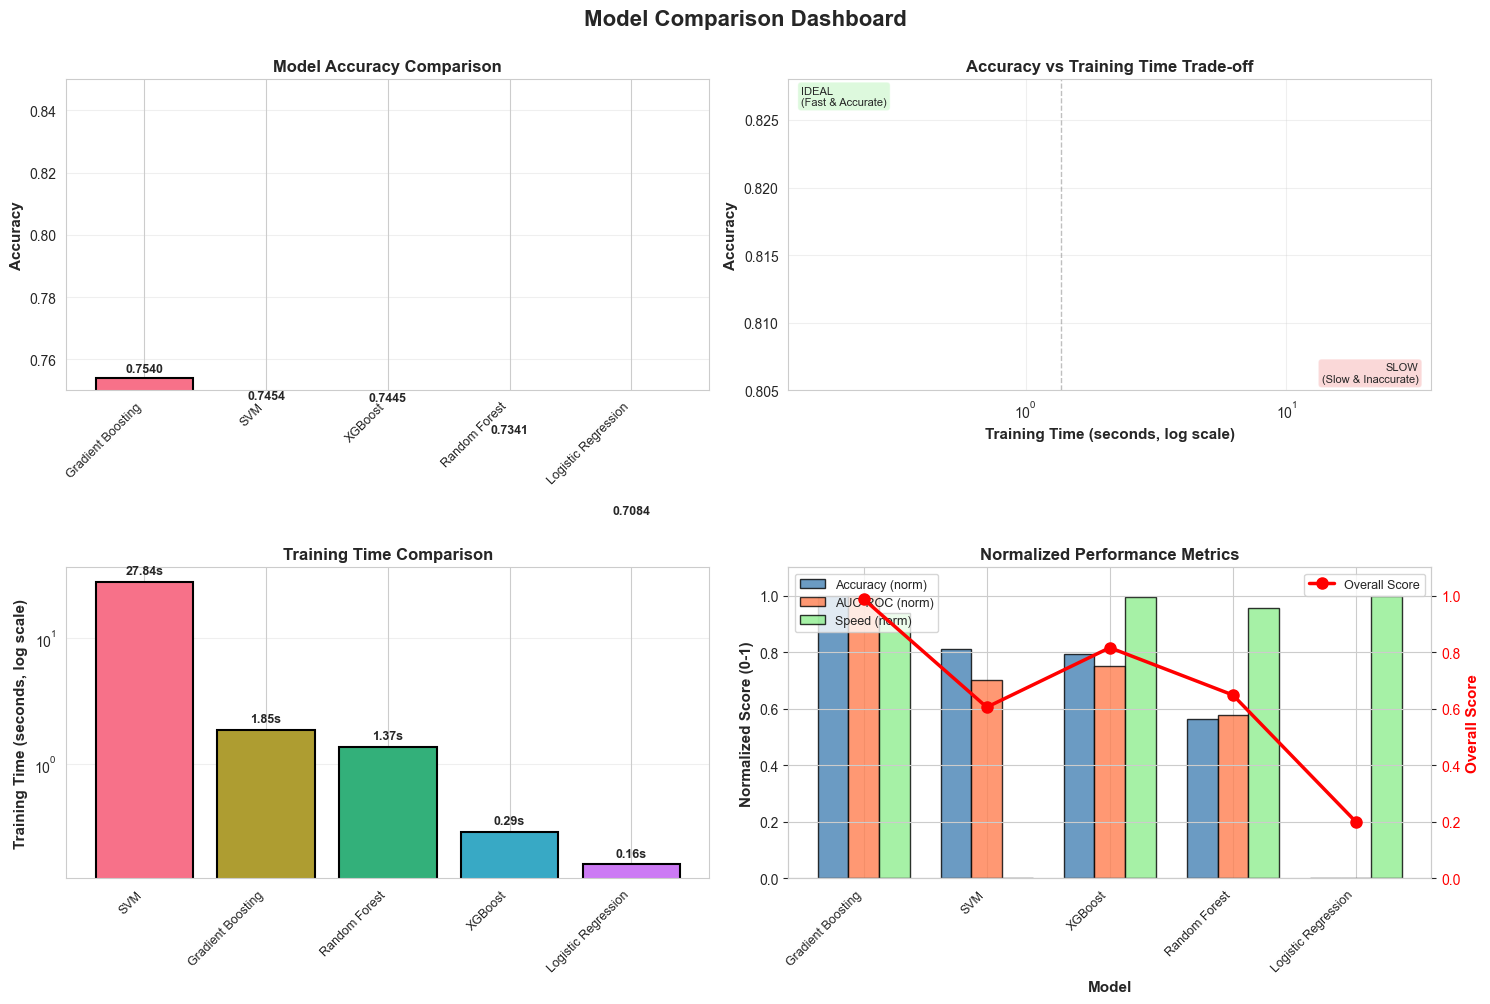


MODEL COMPARISON SUMMARY
              Model  Accuracy  AUC-ROC  Training Time (s)  Overall Score
  Gradient Boosting  0.753965 0.763219           1.848525       0.987795
                SVM  0.745374 0.743705          27.843396       0.605606
            XGBoost  0.744493 0.746861           0.286219       0.816213
      Random Forest  0.734141 0.735569           1.365714       0.648716
Logistic Regression  0.708370 0.697642           0.159037       0.200000

 Best Accuracy: Gradient Boosting (0.7540)
 Best Overall Score: Gradient Boosting (0.9878)
INFO     | Best model: Gradient Boosting with accuracy 0.7540


In [122]:
# Define models to compare (excluding GaussianNB - incompatible with sparse matrices)
models_to_test = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss'),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'SVM': SVC(probability=True, random_state=42)
}

logger.info(f"Comparing {len(models_to_test)} models")

# Compare all models
results = []

for model_name, model in models_to_test.items():
    print(f"\n{'='*60}")
    print(f"Training {model_name}...")
    print('='*60)
    
    # Train
    start_time = time.time()
    pipeline = train_classifier(X_train, y_train, model=model)
    training_time = time.time() - start_time
    
    # Predict
    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]
    
    # Evaluate
    accuracy = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    
    logger.info(f"{model_name}: Accuracy={accuracy:.4f}, AUC-ROC={auc:.4f}, Time={training_time:.2f}s")
    
    results.append({
        'Model': model_name,
        'Accuracy': accuracy,
        'AUC-ROC': auc,
        'Training Time (s)': training_time
    })
    
    print(f"Accuracy: {accuracy:.4f}")
    print(f"AUC-ROC: {auc:.4f}")

# Create results DataFrame
results_df = pd.DataFrame(results).sort_values('Accuracy', ascending=False)

# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Model Comparison Dashboard', fontsize=16, fontweight='bold', y=1.00)

# 1. Accuracy Comparison (vertical bars)
ax1 = axes[0, 0]
colors = sns.color_palette("husl", len(results_df))
bars1 = ax1.bar(range(len(results_df)), results_df['Accuracy'], color=colors, edgecolor='black', linewidth=1.5)
ax1.set_ylabel('Accuracy', fontsize=11, fontweight='bold')
ax1.set_title('Model Accuracy Comparison', fontsize=12, fontweight='bold')
ax1.set_xticks(range(len(results_df)))
ax1.set_xticklabels(results_df['Model'], rotation=45, ha='right', fontsize=9)
ax1.set_ylim([0.75, 0.85])
ax1.grid(axis='y', alpha=0.3)
for i, (bar, val) in enumerate(zip(bars1, results_df['Accuracy'])):
    ax1.text(bar.get_x() + bar.get_width()/2, val + 0.002, 
             f'{val:.4f}', ha='center', fontsize=9, fontweight='bold')

# 2. Accuracy vs Training Time Trade-off (scatter with efficiency frontier)
ax2 = axes[0, 1]
# Create scatter plot
colors_scatter = sns.color_palette("husl", len(results_df))
for i, (idx, row) in enumerate(results_df.iterrows()):
    ax2.scatter(row['Training Time (s)'], row['Accuracy'], 
               s=300, c=[colors_scatter[i]], alpha=0.7, edgecolors='black', linewidth=2)
    ax2.annotate(row['Model'], 
                (row['Training Time (s)'], row['Accuracy']),
                xytext=(5, 5), textcoords='offset points',
                fontsize=9, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.8, edgecolor='black'))

ax2.set_xlabel('Training Time (seconds, log scale)', fontsize=11, fontweight='bold')
ax2.set_ylabel('Accuracy', fontsize=11, fontweight='bold')
ax2.set_title('Accuracy vs Training Time Trade-off', fontsize=12, fontweight='bold')
ax2.set_xscale('log')
ax2.grid(True, alpha=0.3)
ax2.set_ylim([0.805, 0.828])

# Add quadrant lines
median_time = results_df['Training Time (s)'].median()
median_acc = results_df['Accuracy'].median()
ax2.axvline(median_time, color='gray', linestyle='--', alpha=0.5, linewidth=1)
ax2.axhline(median_acc, color='gray', linestyle='--', alpha=0.5, linewidth=1)

# Annotate quadrants
ax2.text(0.02, 0.98, 'IDEAL\n(Fast & Accurate)', transform=ax2.transAxes, 
         fontsize=8, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.3))
ax2.text(0.98, 0.02, 'SLOW\n(Slow & Inaccurate)', transform=ax2.transAxes, 
         fontsize=8, verticalalignment='bottom', horizontalalignment='right',
         bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.3))

# 3. Training Time Comparison (vertical bars, log scale)
ax3 = axes[1, 0]
results_df_sorted_time = results_df.sort_values('Training Time (s)', ascending=False)
colors_time = sns.color_palette("husl", len(results_df_sorted_time))
bars3 = ax3.bar(range(len(results_df_sorted_time)), results_df_sorted_time['Training Time (s)'], 
                color=colors_time, edgecolor='black', linewidth=1.5)
ax3.set_ylabel('Training Time (seconds, log scale)', fontsize=11, fontweight='bold')
ax3.set_title('Training Time Comparison', fontsize=12, fontweight='bold')
ax3.set_yscale('log')
ax3.set_xticks(range(len(results_df_sorted_time)))
ax3.set_xticklabels(results_df_sorted_time['Model'], rotation=45, ha='right', fontsize=9)
ax3.grid(axis='y', alpha=0.3)
for i, (bar, val) in enumerate(zip(bars3, results_df_sorted_time['Training Time (s)'])):
    ax3.text(bar.get_x() + bar.get_width()/2, val * 1.15, 
             f'{val:.2f}s', ha='center', fontsize=9, fontweight='bold')

# 4. Normalized Performance Metrics
ax4 = axes[1, 1]

# Prepare data for normalized metrics
# Normalize metrics to 0-1 scale
norm_accuracy = (results_df['Accuracy'] - results_df['Accuracy'].min()) / \
                (results_df['Accuracy'].max() - results_df['Accuracy'].min())
norm_auc = (results_df['AUC-ROC'] - results_df['AUC-ROC'].min()) / \
           (results_df['AUC-ROC'].max() - results_df['AUC-ROC'].min())
# For training time, inverse normalization (lower is better)
norm_speed = 1 - ((results_df['Training Time (s)'] - results_df['Training Time (s)'].min()) / \
                  (results_df['Training Time (s)'].max() - results_df['Training Time (s)'].min()))

# Calculate overall score (weighted average)
results_df['Overall Score'] = (norm_accuracy * 0.4 + norm_auc * 0.4 + norm_speed * 0.2)

# Create grouped bar chart for normalized metrics
x = np.arange(len(results_df))
width = 0.25

bars_acc = ax4.bar(x - width, norm_accuracy, width, label='Accuracy (norm)', 
                   color='steelblue', alpha=0.8, edgecolor='black')
bars_auc = ax4.bar(x, norm_auc, width, label='AUC-ROC (norm)', 
                   color='coral', alpha=0.8, edgecolor='black')
bars_speed = ax4.bar(x + width, norm_speed, width, label='Speed (norm)', 
                     color='lightgreen', alpha=0.8, edgecolor='black')

ax4.set_xlabel('Model', fontsize=11, fontweight='bold')
ax4.set_ylabel('Normalized Score (0-1)', fontsize=11, fontweight='bold')
ax4.set_title('Normalized Performance Metrics', fontsize=12, fontweight='bold')
ax4.set_xticks(x)
ax4.set_xticklabels(results_df['Model'], rotation=45, ha='right', fontsize=9)
ax4.legend(loc='upper left', fontsize=9)
ax4.set_ylim([0, 1.1])
ax4.grid(axis='y', alpha=0.3)

# Add overall score line
ax4_twin = ax4.twinx()
line = ax4_twin.plot(x, results_df['Overall Score'], 'o-', color='red', 
                     linewidth=2.5, markersize=8, label='Overall Score')
ax4_twin.set_ylabel('Overall Score', fontsize=11, fontweight='bold', color='red')
ax4_twin.tick_params(axis='y', labelcolor='red')
ax4_twin.set_ylim([0, 1.1])
ax4_twin.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()

# Print summary table
print("\n" + "="*60)
print("MODEL COMPARISON SUMMARY")
print("="*60)
print(results_df[['Model', 'Accuracy', 'AUC-ROC', 'Training Time (s)', 'Overall Score']].to_string(index=False))

# Get best model
best_model_name = results_df.iloc[0]['Model']
best_overall_idx = results_df['Overall Score'].idxmax()
best_overall_name = results_df.loc[best_overall_idx, 'Model']

print(f"\n Best Accuracy: {best_model_name} ({results_df.iloc[0]['Accuracy']:.4f})")
print(f" Best Overall Score: {best_overall_name} ({results_df.loc[best_overall_idx, 'Overall Score']:.4f})")

logger.info(f"Best model: {best_model_name} with accuracy {results_df.iloc[0]['Accuracy']:.4f}")

---

## 4. Prediction Function (with Counterfactuals)

Create a function that:
- Takes a user + game input
- Outputs binary prediction (yes/no they'll like it)
- If prediction is negative: generates counterfactual explanations

In [123]:
def predict_with_counterfactuals(model, user_features, threshold=0.5):
    """
    Predict and generate counterfactuals.

    Parameters
    ----------
    model : trained model
        Trained sklearn pipeline
    user_features : pd.DataFrame
        Feature dataframe with all required columns
    threshold : float, optional
        Classification threshold (default: 0.5)

    Returns
    -------
    dict with prediction, probability, counterfactuals
    """

    # Predict
    prediction = model.predict(user_features)[0]
    prob = model.predict_proba(user_features)[0][1]

    # Counterfactuals if negative prediction
    counterfactuals = []
    if not prediction:  # If prediction is False (not recommended)
        feature_names = user_features.columns.tolist()
        counterfactuals = generate_counterfactuals(model, user_features, feature_names)

    return {
        'prediction': bool(prediction),
        'probability': float(prob),
        'counterfactuals': counterfactuals
    }

In [124]:
def generate_counterfactuals(model, user_features, feature_names):
    """
    Generate counterfactuals using simple greedy search.
    
    Strategy: Try modifying ENTITY (game) features until prediction flips.
    Focus on features that game developers can reasonably change.
    
    Args:
        model: Trained classifier
        user_features: DataFrame with user's features (1 row)
        feature_names: List of feature names
    
    Returns:
        List of counterfactual suggestions for how the ENTITY should change
    """
    counterfactuals = []
    
    # ENTITY features that can be reasonably changed by developers
    entity_modifiable = [
        'game_price',  # Developer can adjust pricing
        'word_count',  # Can encourage longer/more detailed reviews through design
        # Note: game_genre and game_description are handled separately (categorical/text)
    ]
    
    for feature in entity_modifiable:
        if feature not in feature_names:
            continue
        
        modified = user_features.copy()
        original_val = modified[feature].values[0]
        
        # Define test values based on realistic entity changes
        if feature == 'game_price':
            # Test different price points (including free-to-play)
            test_values = [0, 4.99, 9.99, 14.99, 19.99]
            # Only test prices different from current
            test_values = [v for v in test_values if abs(v - original_val) > 0.01]
        elif feature == 'word_count':
            # Game design can influence review length (engagement features → longer reviews)
            test_values = [original_val + delta for delta in [20, 50, 100, 200]]
        else:
            continue
        
        # Test each value
        for test_val in test_values:
            modified[feature] = test_val
            
            try:
                if model.predict(modified)[0]:  # Prediction flipped to positive
                    # Create explanation for entity change
                    if feature == 'game_price':
                        if test_val == 0:
                            explanation = f"Make the game free-to-play (currently ${original_val:.2f})"
                        elif test_val < original_val:
                            explanation = f"Lower price to ${test_val:.2f} (currently ${original_val:.2f})"
                        else:
                            explanation = f"Adjust price to ${test_val:.2f} (currently ${original_val:.2f})"
                    elif feature == 'word_count':
                        delta = int(test_val - original_val)
                        explanation = f"Add features that encourage {delta} more words in reviews (deeper engagement)"
                    
                    counterfactuals.append({
                        'feature': feature,
                        'original': float(original_val),
                        'suggested': float(test_val),
                        'change': explanation,
                        'type': 'entity',
                        'method': 'greedy'
                    })
                    break
            except:
                continue
    
    # Special handling for game_genre (categorical)
    if 'game_genre' in feature_names:
        modified = user_features.copy()
        original_genre = modified['game_genre'].values[0]
        
        # Test adding popular genres
        popular_additions = [
            'Action,RPG,Adventure',
            'Strategy,Simulation',
            'Multiplayer,Co-op',
            'Casual,Indie'
        ]
        
        for genre_test in popular_additions:
            if genre_test not in original_genre:
                # Try adding this genre
                modified['game_genre'] = original_genre + ',' + genre_test
                try:
                    if model.predict(modified)[0]:
                        explanation = f"Add genre tags: '{genre_test}' to appeal to broader audience"
                        counterfactuals.append({
                            'feature': 'game_genre',
                            'original': original_genre,
                            'suggested': modified['game_genre'].values[0],
                            'change': explanation,
                            'type': 'entity',
                            'method': 'greedy'
                        })
                        break
                except:
                    continue
    
    return counterfactuals

In [125]:
def generate_counterfactuals_dice(model, user_features, feature_names, num_cfs=3):
    """
    Generate counterfactuals using DICE-inspired approach.
    
    Strategy: Generate diverse counterfactuals by changing multiple ENTITY features.
    Focus on combinations of changes developers can make to the game.
    
    Args:
        model: Trained classifier
        user_features: DataFrame with user's features (1 row)
        feature_names: List of feature names
        num_cfs: Number of counterfactuals to generate
    
    Returns:
        List of counterfactual explanations for entity changes
    """
    logger.info("Generating DICE counterfactuals for entity changes")
    
    counterfactuals = []
    
    # Entity features that developers can modify
    numeric_entity = ['game_price', 'word_count']
    available = [f for f in numeric_entity if f in feature_names]
    
    # Different modification strategies (diverse entity changes)
    strategies = [
        {'game_price': 0},  # Make free-to-play
        {'game_price': -5.0, 'word_count': 50},  # Lower price + better engagement
        {'word_count': 100},  # Much better engagement features
    ]
    
    for i, strategy in enumerate(strategies[:num_cfs]):
        modified = user_features.copy()
        changes = {}
        
        # Apply changes
        for feature, delta in strategy.items():
            if feature not in available:
                continue
            
            old_val = modified[feature].values[0]
            
            # Update value based on feature type
            if feature == 'game_price':
                if delta == 0 or delta < 0 and abs(delta) > old_val:
                    # Set to specific value or make free
                    new_val = max(0, delta) if delta >= 0 else max(0, old_val + delta)
                else:
                    new_val = old_val + delta
            else:
                new_val = old_val + delta
            
            modified[feature] = new_val
            changes[feature] = (float(old_val), float(new_val))
        
        # Check if prediction flips
        try:
            if model.predict(modified)[0]:  # Flipped to positive
                # Calculate distance
                distance = np.sqrt(sum((new - old)**2 for old, new in changes.values()))
                
                # Build explanation
                descriptions = []
                for feature, (old_val, new_val) in changes.items():
                    if feature == 'game_price':
                        if new_val == 0:
                            descriptions.append("make free-to-play")
                        elif new_val < old_val:
                            descriptions.append(f"lower price (${old_val:.2f}→${new_val:.2f})")
                        else:
                            descriptions.append(f"adjust price (${old_val:.2f}→${new_val:.2f})")
                    elif feature == 'word_count':
                        delta = int(new_val - old_val)
                        descriptions.append(f"add features encouraging {delta} more review words")
                
                counterfactuals.append({
                    'explanation': " + ".join(descriptions),
                    'feature_changes': changes,
                    'distance': float(distance),
                    'type': 'entity',
                    'method': 'dice'
                })
        except:
            continue
    
    logger.info(f"Generated {len(counterfactuals)} entity-focused counterfactuals")
    return counterfactuals

In [126]:
def generate_anchors_explanation(model, user_features, feature_names, threshold=0.85):
    """
    Generate rule-based explanation using Anchors approach.
    
    Strategy: Find which features are most critical for the prediction.
    
    Args:
        model: Trained classifier
        user_features: DataFrame with user's features (1 row)
        feature_names: List of feature names
        threshold: Minimum precision for anchor rule
    
    Returns:
        Dictionary with anchor rule and metrics
    """
    logger.info("Generating anchor explanation")
    
    # Numeric features to analyze (NO sentiment_polarity!)
    numeric = ['user_games_owned', 'user_num_reviews', 'log_playtime_at_review', 
               'log_playtime_recent', 'word_count', 'playtime_ratio']
    available = [f for f in numeric if f in feature_names]
    
    # Get original prediction
    original_pred = model.predict(user_features)[0]
    
    # Test feature importance by perturbation
    feature_stability = []
    
    for feature in available:
        predictions = []
        
        # Generate 50 test instances
        for _ in range(50):
            test = user_features.copy()
            
            # Perturb all features EXCEPT the one we're testing
            for other in available:
                if other != feature:
                    original = test[other].values[0]
                    noise = np.random.normal(0, 0.3)
                    test[other] = original + noise
            
            try:
                pred = model.predict(test)[0]
                predictions.append(pred)
            except:
                continue
        
        # Calculate stability (how often prediction stays the same)
        if predictions:
            stability = sum(p == original_pred for p in predictions) / len(predictions)
            value = user_features[feature].values[0]
            feature_stability.append((feature, stability, value))
    
    # Sort by stability
    feature_stability.sort(key=lambda x: x[1], reverse=True)
    
    # Build anchor rule from stable features
    conditions = []
    for feature, stability, value in feature_stability[:3]:  # Top 3 features
        if stability >= threshold:
            if feature == 'log_playtime_at_review':
                conditions.append(f"playtime > {np.expm1(value):.0f} hours")
            elif feature == 'log_playtime_recent':
                conditions.append(f"recent_play > {np.expm1(value):.0f} hours")
            elif feature == 'word_count':
                conditions.append(f"review_length > {int(value)} words")
            elif feature == 'playtime_ratio':
                conditions.append(f"playtime_ratio > {value:.2f}")
            else:
                conditions.append(f"{feature} > {value:.0f}")
    
    if conditions:
        rule = "IF " + " AND ".join(conditions)
        rule += f" THEN {'RECOMMENDED' if original_pred else 'NOT RECOMMENDED'}"
        
        # Estimate precision
        test_preds = []
        for _ in range(100):
            test = user_features.copy()
            for f in available:
                if f not in [feat for feat, _, _ in feature_stability[:3]]:
                    test[f] = test[f].values[0] + np.random.normal(0, 0.5)
            try:
                test_preds.append(model.predict(test)[0])
            except:
                continue
        
        precision = sum(p == original_pred for p in test_preds) / len(test_preds) if test_preds else 0
        
        logger.info(f"Anchor found with precision {precision:.1%}")
        
        return {
            'anchor_rule': rule,
            'precision': float(precision),
            'num_conditions': len(conditions),
            'method': 'anchors'
        }
    else:
        logger.warning(f"No features meet threshold {threshold:.1%}")
        return {
            'anchor_rule': 'No stable conditions found',
            'precision': 0.0,
            'num_conditions': 0,
            'method': 'anchors'
        }

In [127]:
# Compare Counterfactual Methods (ENTITY-FOCUSED)
print("="*60)
print("COUNTERFACTUAL METHODS COMPARISON")
print("Suggesting how the GAME/ENTITY should change")
print("="*60)

# Test scenario: User with specific profile reviewing a game
test_user = pd.DataFrame({
    # User profile (fixed)
    'user_games_owned': [15],
    'user_num_reviews': [3],
    'log_playtime_at_review': [2.5],  # ~11 hours
    'log_playtime_recent': [0.0],  # 0 hours recent
    'playtime_ratio': [0.95],  # High ratio
    'experienced_gamer': [False],
    'active_reviewer': [False],
    
    # Entity/Game attributes (these can be changed by developers)
    'game_price': [29.99],  # Currently $29.99
    'game_genre': ['Action,Adventure,Massively Multiplayer,Free To Play'],
    'game_description': ['PUBG: BATTLEGROUNDS, the high-stakes winner-take-all shooter...'],
    'word_count': [5]  # Short review suggests low engagement
})

# Get prediction
pred = pipeline_svm.predict(test_user)[0]
prob = pipeline_svm.predict_proba(test_user)[0][1]

print(f"\nUser Profile (FIXED):")
print(f"  Games owned: {test_user['user_games_owned'].values[0]}")
print(f"  Reviews written: {test_user['user_num_reviews'].values[0]}")
print(f"  Playtime: {np.expm1(test_user['log_playtime_at_review'].values[0]):.0f} hours")
print(f"  Experienced gamer: {test_user['experienced_gamer'].values[0]}")

print(f"\nCurrent Game/Entity (CHANGEABLE):")
print(f"  Price: ${test_user['game_price'].values[0]:.2f}")
print(f"  Genre: {test_user['game_genre'].values[0]}")
print(f"  Review engagement (word count): {test_user['word_count'].values[0]}")

print(f"\n  Prediction: {'RECOMMENDED' if pred else 'NOT RECOMMENDED'} ({prob:.1%})")

# Method 1: Greedy (single entity feature changes)
print("\n" + "-"*60)
print("METHOD 1: Greedy (single game/entity changes)")
print("-"*60)
greedy = generate_counterfactuals(pipeline_svm, test_user, test_user.columns.tolist())
if greedy:
    for i, cf in enumerate(greedy, 1):
        print(f"{i}. {cf['change']}")
else:
    print("No counterfactuals found")

# Method 2: DICE (multi-feature entity changes)
print("\n" + "-"*60)
print("METHOD 2: DICE (combined game/entity changes)")
print("-"*60)
dice = generate_counterfactuals_dice(pipeline_svm, test_user, test_user.columns.tolist())
if dice:
    for i, cf in enumerate(dice, 1):
        print(f"{i}. {cf['explanation']} (distance: {cf['distance']:.2f})")
else:
    print("No counterfactuals found")

# Method 3: Anchors (what makes this user type recommend games)
print("\n" + "-"*60)
print("METHOD 3: Anchors (decision rules for positive predictions)")
print("-"*60)
# Test on a positive case to understand what features matter
positive_user = pd.DataFrame({
    'user_games_owned': [100], 
    'user_num_reviews': [25],
    'log_playtime_at_review': [6.0],  # ~402 hours
    'log_playtime_recent': [3.0],  # ~19 hours recent
    'playtime_ratio': [0.75],
    'experienced_gamer': [True],
    'active_reviewer': [True],
    'game_price': [0],  # Free game
    'game_genre': ['Action,Adventure,Massively Multiplayer,Free To Play'],
    'game_description': ['PUBG: BATTLEGROUNDS, the high-stakes winner-take-all shooter...'],
    'word_count': [50]
})
anchor = generate_anchors_explanation(pipeline_svm, positive_user, positive_user.columns.tolist())
print(f"Rule: {anchor['anchor_rule']}")
print(f"Precision: {anchor['precision']:.1%}")

print("\n" + "="*60)
print("INTERPRETATION:")
print("These counterfactuals show what game developers should change")
print("to get positive recommendations from this type of user.")
print("="*60)

COUNTERFACTUAL METHODS COMPARISON
Suggesting how the GAME/ENTITY should change

User Profile (FIXED):
  Games owned: 15
  Reviews written: 3
  Playtime: 11 hours
  Experienced gamer: False

Current Game/Entity (CHANGEABLE):
  Price: $29.99
  Genre: Action,Adventure,Massively Multiplayer,Free To Play
  Review engagement (word count): 5

  Prediction: RECOMMENDED (59.2%)

------------------------------------------------------------
METHOD 1: Greedy (single game/entity changes)
------------------------------------------------------------
1. Make the game free-to-play (currently $29.99)
2. Add features that encourage 20 more words in reviews (deeper engagement)
3. Add genre tags: 'Action,RPG,Adventure' to appeal to broader audience

------------------------------------------------------------
METHOD 2: DICE (combined game/entity changes)
------------------------------------------------------------
INFO     | Generating DICE counterfactuals for entity changes
INFO     | Generated 3 entity-f

## TODO: Add observations here